In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as spintp

from glob import glob
import netCDF4
import time

import isolar
import spectrumLib

---

Allen continuum new vs E490

In [2]:
wl_arr = np.linspace(2000,30000,241)
# [erg/cm^2/A/s/rad^2]
itens_allen = isolar.isolar(wl_arr, continuum_new=1)

In [3]:
file = "./data/ASTM_E490.dat"
J2erg_ = 1.E+7
# [W/m^2/um] -> [erg/cm^2/A/s/rad^2]
fac_unit = 1e-4 * 1e-4 * J2erg_ / ((16 / 60 / 180 * np.pi)**2 * np.pi)
astm_arr = np.loadtxt(file, skiprows=2)
astm_arr[:,0] *= 1.E4 # unit conversion : [um] to [A]
astm_arr[:,1] *= fac_unit
astm_arr.shape
del file

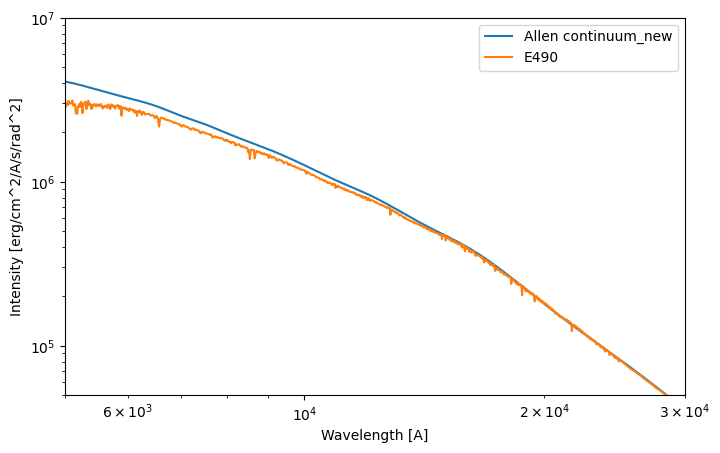

In [7]:

fac_e490 = 1.065

fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=100)
ax.plot(wl_arr, itens_allen, label='Allen continuum_new')
ax.plot(astm_arr[:,0], astm_arr[:,1]*fac_e490, label='E490')
#ax.plot(astm_arr[:,0], astm_arr[:,1], label='E490')
#ax.set_xlim(0,3E4)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Wavelength [A]")
ax.set_ylim(5E4,1E7)
ax.set_xlim(5000,30000)
#ax.set_xlim(0,10000)
ax.set_ylabel("Intensity [erg/cm^2/A/s/rad^2]")
ax.legend(loc='best')
plt.show()

In [8]:
astm_arr[:,1] *= fac_e490

---

In [9]:
fname = {}
data_folders =  ("670-1609A", "3000-10000A", "10000-26000A")
for fd in data_folders:
    fname[fd] = sorted(glob(f"./data/{fd}/*.txt"), key=lambda x:int(x.split("/")[-1].split("_")[1][2:]) )
del fd

In [41]:
data = {"wave" : {}, "flux": {}}

## bass2000: 3000-11000A

read 3000-10000A wavelength and flux data

In [42]:
folder = '3000-10000A'
print(f"processing {folder}")
# wavelength : [A]; flux : normalized
data["wave"][folder], data["flux"][folder] = spectrumLib.read_spectral_folder(fname[folder])

processing 3000-10000A


read 10000-11000A wavelength and flux data

In [60]:
folder = '10000-11000A'
print(f"processing {folder}")
# wavelength : [A]; flux : normalized
data["wave"][folder], data["flux"][folder] = spectrumLib.read_spectral_folder(fname['10000-26000A'])

mask = (data["wave"][folder] > data["wave"]['3000-10000A'][-1]) * (data["wave"][folder] <= 11000)
data["wave"][folder] = data["wave"][folder][mask]
data["flux"][folder] = data["flux"][folder][mask]


processing 10000-11000A


merge 3000-10000A and 10000-11000A 

In [61]:
data["wave"].keys(), data["wave"]["3000-10000A"][-1], data["wave"]["10000-11000A"][0]

(dict_keys(['3000-10000A', '10000-11000A', '3000-11000A']),
 9999.998,
 9999.9993)

In [62]:
for key, val in data.items():
    val["3000-11000A"] = np.append( val["3000-10000A"], val["10000-11000A"] )
del key, val

In [65]:
data["wave"]["3000-11000A"][3616754] == 10500.0008,data["wave"]["3000-11000A"][3724949] == 11000

(True, True)

In [66]:
data["wave"]["3000-11000A"].size == data["wave"]["3000-10000A"].size + data["wave"]["10000-11000A"].size

True

convert wavelength from "air" to "vacuum"

In [67]:
folder = "3000-11000A"

In [68]:
print(f'original : {data["wave"][folder][0]:.4f} -> {data["wave"][folder][-1]:.4f}')
data["wave"][folder][:] = spectrumLib.air_to_vacuum(data["wave"][folder][:])
print(f'after    : {data["wave"][folder][0]:.4f} -> {data["wave"][folder][-1]:.4f}')

original : 3000.0000 -> 11000.0000
after    : 3000.8183 -> 11003.0193


is wavelength in asending order ?

In [69]:
(np.diff( data["wave"][folder])>0).all()

True

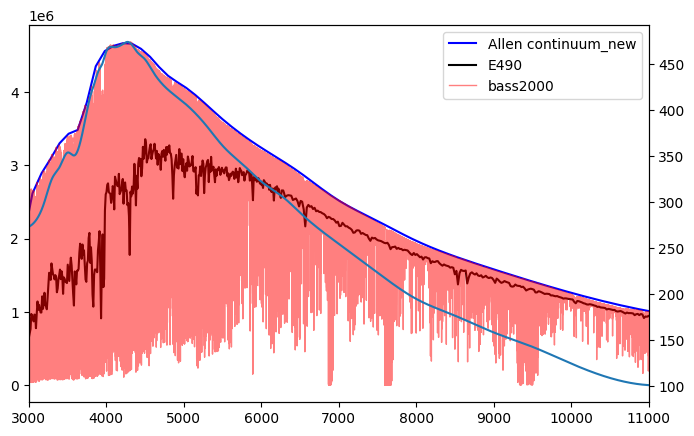

In [72]:
with open(f"./data.20220801/scale_{folder}.txt", 'r') as f:
    lns = f.readlines()

index_ = []
wavel_ = []
scale_ = []
for ln in lns[1:]:
    words = ln.split()
    index_.append(int(words[0]))
    wavel_.append(float(words[1]))
    scale_.append(float(words[2]))
    

Bsp_obj_ = spintp.splrep(x=np.array(wavel_), y=np.array(scale_), k=3)
# ext=3 : return boundary value
iL, iR = index_[0], index_[-1]
scale_interp_ = spintp.splev(data["wave"][folder][iL:iR+1], Bsp_obj_, ext=3)
scale_interp_[:] *= 2.6E-8

wL = data["wave"][folder][iL]
wR = data["wave"][folder][iR]

wave_  = data["wave"][folder][iL:iR+1]
flux_  = data["flux"][folder][iL:iR+1]

fig ,ax = plt.subplots(1,1, figsize=(8,5), dpi=100)
ax.plot(wl_arr, itens_allen, "b-", label='Allen continuum_new')
ax.plot(astm_arr[:,0], astm_arr[:,1], "k-", label="E490")
ax.plot(wave_, flux_[:]*scale_interp_[:], "r-", linewidth=1, alpha=0.5, label="bass2000")
#ax.plot(wave_, flux_[:], "r-", linewidth=1, alpha=0.5, label="bass2000")

ax1 = ax.twinx()
ax1.plot(wave_, scale_interp_)

#ax.set_yscale("log")
#ax.set_xlim(wL-100, wR+100)
#ax.set_xlim(3000,10000)
ax.set_xlim(3000,11000)
ax.legend()
plt.show()

In [75]:
data["wave"][folder] = wave_
data["flux"][folder] = flux_[:]*scale_interp_[:]

## E490 : 9000-50000A

find start index of 9000A

In [77]:
folder = "11000A-0.1CM"

In [78]:
idx1 = np.where( astm_arr[:,0] > 9000 )[0][0]
idx2 = np.where(  15000 > astm_arr[:,0] )[0][-1]
idx1, idx2

(647, 945)

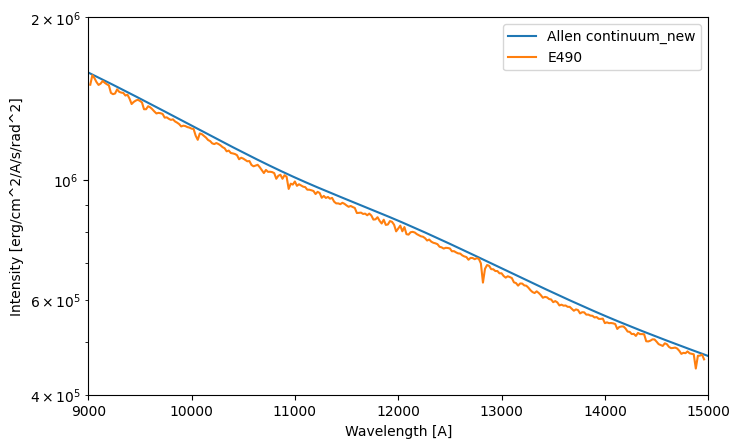

In [79]:
#fac_e490 = np.ones_like(astm_arr[idx:,0])

Bsp_obj_ = spintp.splrep(x=[astm_arr[idx1,0],astm_arr[idx2-1,0]], y=[1.075,1], k=1)
scale_interp_ = spintp.splev(astm_arr[idx1:idx2,0], Bsp_obj_, ext=3)



fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=100)
ax.plot(wl_arr, itens_allen, label='Allen continuum_new')
ax.plot(astm_arr[idx1:idx2,0], astm_arr[idx1:idx2,1]*scale_interp_, label='E490')
#ax.set_xlim(0,3E4)
ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel("Wavelength [A]")
ax.set_xlim(9000, 15000)
ax.set_ylim(4E5,2E6)
#ax.set_ylim(5E4,1E6)
ax.set_ylabel("Intensity [erg/cm^2/A/s/rad^2]")
ax.legend()
plt.show()

In [80]:
idx11 = np.where( astm_arr[:,0] > data["wave"]["3000-11000A"][-1] )[0][0]
idx22 = np.where(  15000 > astm_arr[:,0] )[0][-1]
idx11, idx22, astm_arr[idx11,0], astm_arr[idx22,0]

(747, 945, 11020.0, 14980.0)

In [81]:
scale_all_ = np.ones_like(astm_arr[idx11:,0])
scale_all_[:idx22-idx11] = scale_interp_[idx11-idx1:]

data["wave"][folder] = astm_arr[idx11:,0]
data["flux"][folder] = astm_arr[idx11:,1] * scale_all_[:]

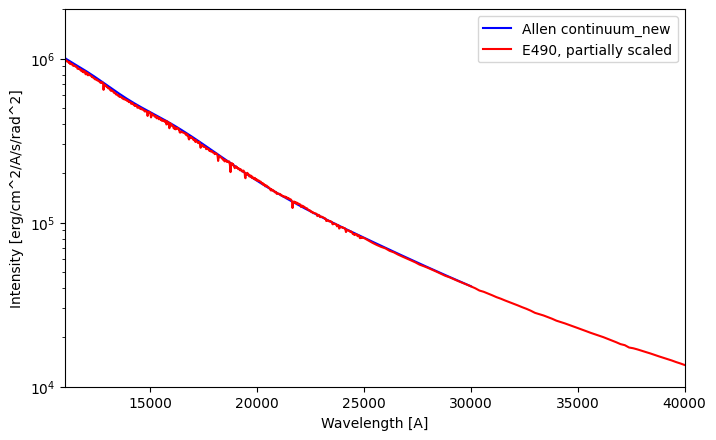

In [83]:
fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=100)
ax.plot(wl_arr, itens_allen, "b-", label='Allen continuum_new', linewidth=1.5)
ax.plot(data["wave"][folder], data["flux"][folder],'r-', label='E490, partially scaled')
#ax.set_xlim(0,3E4)
ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel("Wavelength [A]")
ax.set_xlim(11000, 40000)
#ax.set_ylim(4E5,2E6)
ax.set_ylim(1E4,2E6)
ax.set_ylabel("Intensity [erg/cm^2/A/s/rad^2]")
ax.legend()
plt.show()

# bass2000: 670-1609A

In [84]:
folder = data_folders[0]
print(f"processing {folder}")
# wavelength : [A]; flux : normalized
data["wave"][folder], data["flux"][folder] = spectrumLib.read_spectral_folder(fname[folder])

processing 670-1609A
reorder at 676.06385[AA]


is wavelength in asending order ?

In [85]:
(np.diff( data["wave"][folder])>0).all()

True

In [86]:
np.diff(data["wave"][folder])[:10]

array([0.04482, 0.04482, 0.04482, 0.04482, 0.04482, 0.04482, 0.04482,
       0.04482, 0.04482, 0.04482])

sampling
- E490 : 10A
- bass2000 : 0.045

~45 points for averaging

In [87]:
avg_r = int( 10 // 0.045 )

In [88]:
wl_avg = []
inten_avg = []

for i in range(0,data["wave"][folder].size//avg_r):
    wl = data["wave"][folder][i*avg_r:i*avg_r+avg_r].mean()
    inten = data["flux"][folder][i*avg_r:i*avg_r+avg_r].mean()
    wl_avg.append(wl)
    inten_avg.append(inten)

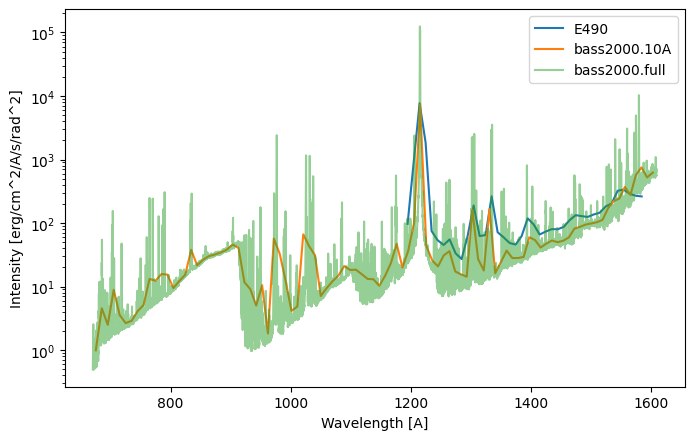

In [89]:
fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=100)

ax.plot(astm_arr[:40,0], astm_arr[:40,1], label='E490')
ax.plot(np.array(wl_avg), np.array(inten_avg), label='bass2000.10A')
ax.plot(data["wave"][folder], data["flux"][folder], alpha=0.5, label='bass2000.full')
#ax.set_xlim(0,3E4)
ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlabel("Wavelength [A]")
#ax.set_xlim(9000, 15000)
#ax.set_ylim(4E5,2E6)
ax.set_ylabel("Intensity [erg/cm^2/A/s/rad^2]")
ax.legend()
plt.show()

## SORCE : 1150-3100A

In [90]:
nc = netCDF4.Dataset('./SORCE_SOLSTICE_L3_HR_V16_2018.nc', 'r')

In [91]:
k = 100
# 20180411, full disk average, quiet Sun
# wavelength resolution : 1A

In [92]:
nc.variables["nominal_date_yyyymmdd"][k]

masked_array(data=20180411.5,
             mask=False,
       fill_value=1e+20)

In [93]:
# nm
nc.variables["standard_wavelengths"].shape

(7800,)

In [94]:
# W/m^2/nm
nc.variables["irradiance"].shape

(365, 7800)

In [95]:
folder = "1150-3100A"

In [96]:
# [nm] -> [A]
data["wave"][folder] = nc.variables["standard_wavelengths"][:].data * 10
# W/m^2/nm -> [erg/cm^2/A/s/rad^2]
fac_sorce = fac_unit * 1E3
data["flux"][folder] = nc.variables["irradiance"][:,:].data.mean(axis=0) * fac_sorce

C:\Users\lelou\AppData\Local\Temp\ipykernel_17776\2061088068.py:5: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  data["flux"][folder] = nc.variables["irradiance"][:,:].data.mean(axis=0) * fac_sorce


In [175]:
np.diff(data["wave"][folder]), np.diff(data["wave"]["3000-10000A"])

(array([0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25]),
 array([0.00200055, 0.00200055, 0.00200055, ..., 0.00200055, 0.00200055,
        0.00200055]))

In [101]:
avg_r = int( 0.25/0.002 )
wl_avg = []
inten_avg = []

for i in range(0,data["wave"]["3000-11000A"].size//avg_r):
    wl = data["wave"]["3000-11000A"][i*avg_r:i*avg_r+avg_r].mean()
    inten = data["flux"]["3000-11000A"][i*avg_r:i*avg_r+avg_r].mean()
    wl_avg.append(wl)
    inten_avg.append(inten)

In [103]:
avg_r = int(0.25/0.045)
wl_avg0 = []
inten_avg0 = []

for i in range(0,data["wave"]["670-1609A"].size//avg_r):
    wl = data["wave"]["670-1609A"][i*avg_r:i*avg_r+avg_r].mean()
    inten = data["flux"]["670-1609A"][i*avg_r:i*avg_r+avg_r].mean()
    wl_avg0.append(wl)
    inten_avg0.append(inten)

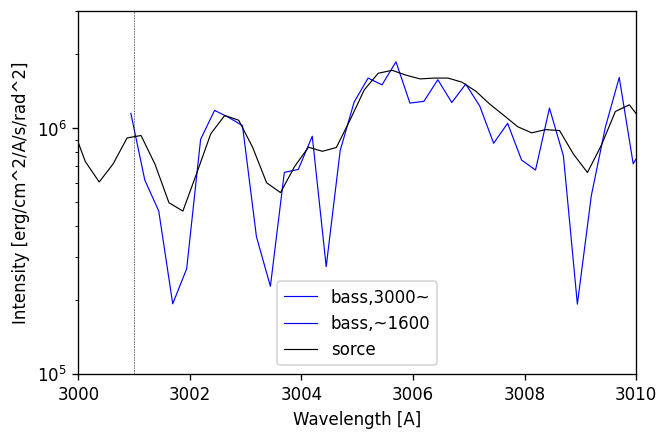

In [105]:
fig, ax = plt.subplots(1,1, figsize=(6,4), dpi=120)

#ax.plot(data["wave"]["3000-10000A"], data["flux"]["3000-10000A"], "b-", lw=0.7, label="bass")
ax.plot(wl_avg, inten_avg, "b-", lw=0.7, label="bass,3000~")
ax.plot(wl_avg0, inten_avg0, "b-", lw=0.7, label="bass,~1600")

#ax.plot(data["wave"]["1150-3100A"], 6.5*data["flux"]["1150-3100A"], "k-", lw=0.7, label="sorce")
ax.plot(data["wave"]["1150-3100A"], 2*data["flux"]["1150-3100A"], "k-", lw=0.7, label="sorce")

wv0, wv1 = 1595, 3001
ax.axvline(wv0, color="black", linestyle='--', linewidth=0.3)
ax.axvline(wv1, color='black', linestyle='--', linewidth=0.3)


ax.set_ylim(1E5,3E6)
ax.set_xlim(3000, 3010)


#ax.set_xlim(1550, 1700)
#ax.set_ylim(1E2,1E3)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("Intensity [erg/cm^2/A/s/rad^2]")
ax.set_yscale("log")
ax.legend()
plt.show()

In [106]:
data["flux"]["1150-3100A"][:] *= 2

cut range

In [108]:
wv0, wv1

(1595, 3001)

In [109]:
# cut "1150-3100A"
folder = "1150-3100A"
idx0 = np.where( data["wave"][folder] >= wv0 )[0][0]
idx1 = np.where( data["wave"][folder] <= wv1 )[0][-1]
idx_all = data["wave"][folder].size
print(f"cutting {folder} between [{idx0},{idx1}] in [0,{idx_all}]")
data["wave"][folder] = data["wave"][folder][idx0:idx1+1]
data["flux"][folder] = data["flux"][folder][idx0:idx1+1]

folder = "670-1609A"
idx1 = np.where( data["wave"][folder] < wv0 )[0][-1]
idx_all = data["wave"][folder].size
print(f"cutting {folder} between [0,-{idx_all-idx1}] in [0,{idx_all}]")
data["wave"][folder] = data["wave"][folder][:idx1+1]
data["flux"][folder] = data["flux"][folder][:idx1+1]

folder = "3000-11000A"
idx0 = np.where( data["wave"][folder] > wv1 )[0][0]
idx_all = data["wave"][folder].size
print(f"cutting {folder} between [{idx0},{idx_all}] in [0,{idx_all}]")
data["wave"][folder] = data["wave"][folder][idx0:]
data["flux"][folder] = data["flux"][folder][idx0:]

cutting 1150-3100A between [1780,7403] in [0,7800]
cutting 670-1609A between [0,-340] in [0,21565]
cutting 3000-11000A between [91,3724950] in [0,3724950]


In [115]:
print(data["wave"]["670-1609A"][0],data["wave"]["670-1609A"][-1])
print(data["wave"]["1150-3100A"][0],data["wave"]["1150-3100A"][-1])
print(data["wave"]["3000-11000A"][0],data["wave"]["3000-11000A"][-1])


670.57004 1594.9837
1595.125 3000.875
3001.000301572156 11003.01932111621


## SORCE: 1-400A

In [116]:
nc = netCDF4.Dataset('./sorce_xps_L4_c05m_r0.1nm_v11_20180101_20181231.ncdf', 'r')

In [117]:
np.where( nc.variables["DATE"][:]==2018101 )[0].mean()

8590.5

In [118]:
k = 8590
nc.variables["DATE"][k]

masked_array(data=2018101,
             mask=False,
       fill_value=999999)

In [119]:
nc.variables["TIME"][k].data

array(24860.256, dtype=float32)

In [120]:
time.strftime('%H:%M:%S', time.gmtime(nc.variables["TIME"][k].data))

TypeError: only integer scalar arrays can be converted to a scalar index

In [121]:
folder = "1-400A"

In [122]:
data["wave"][folder] = np.arange(1,401,dtype=np.float32)
data["flux"][folder] = nc.variables["MODELFLUX"][k,:].data

In [123]:
avg_r = int(1/0.045)
wl_avg0 = []
inten_avg0 = []

for i in range(0,data["wave"]["670-1609A"].size//avg_r):
    wl = data["wave"]["670-1609A"][i*avg_r:i*avg_r+avg_r].mean()
    inten = data["flux"]["670-1609A"][i*avg_r:i*avg_r+avg_r].mean()
    wl_avg0.append(wl)
    inten_avg0.append(inten)

In [124]:
astm_arr0 = np.loadtxt("/Users/liu/kouui/workspace/spectra/data/intensity/continuum/ASTM_E490+PROM7_HI_CaII.dat",dtype=np.double, skiprows=2)
astm_arr0[:,0] *= 1.E8 # unit conversion : [cm] to [A]
astm_arr0[:,1] /= 3

FileNotFoundError: /Users/liu/kouui/workspace/spectra/data/intensity/continuum/ASTM_E490+PROM7_HI_CaII.dat not found.

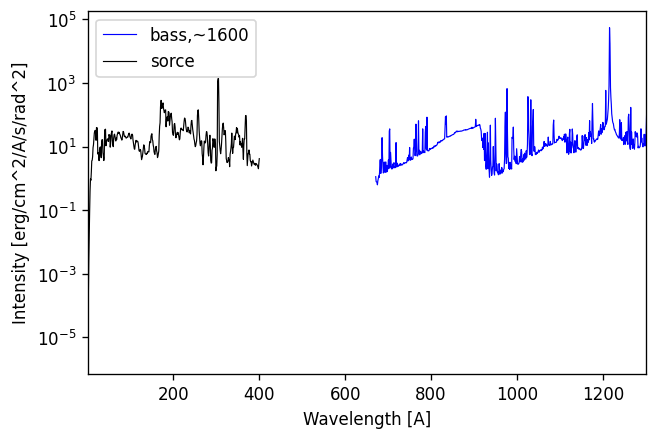

In [125]:
fig, ax = plt.subplots(1,1, figsize=(6,4), dpi=120)

ax.plot(wl_avg0, inten_avg0, "b-", lw=0.7, label="bass,~1600")

#ax.plot(data["wave"]["1150-3100A"], 6.5*data["flux"]["1150-3100A"], "k-", lw=0.7, label="sorce")
ax.plot(data["wave"][folder], data["flux"][folder]*1E6, "k-", lw=0.7, label="sorce")

#ax.plot(astm_arr0[:,0], 2E-8*astm_arr0[:,1], "ro--", lw=0.7, label="OSO7", markersize=1)

#ax.set_xlim(1100, 1700)
ax.set_xlim(1, 1300)
#ax.set_xlim(3000, 3300)
#ax.set_xlim(3000, 3100)
#ax.set_ylim(1E5,3E6)
#ax.set_ylim(1E2,1E3)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("Intensity [erg/cm^2/A/s/rad^2]")
ax.set_yscale("log")
ax.legend()
plt.show()

In [126]:
data["flux"][folder] *= 1E6

---

save file

In [127]:
data["wave"].keys()

dict_keys(['3000-10000A', '10000-11000A', '3000-11000A', '11000A-0.1CM', '670-1609A', '1150-3100A', '1-400A'])

In [128]:
waves  = np.array([],dtype="float64")
intens = np.array([],dtype="float64")
for key in ('1-400A','670-1609A','1150-3100A','3000-11000A','11000A-0.1CM'):
    waves  = np.append(waves,data["wave"][key])
    intens = np.append(intens,data["flux"][key])

In [129]:
waves.shape, intens.shape

((3753059,), (3753059,))

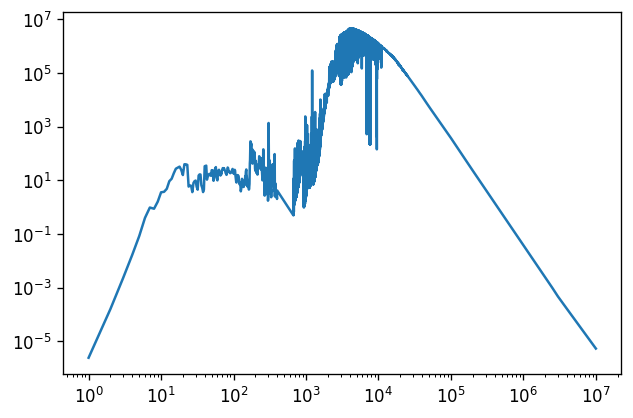

In [130]:
fig, ax = plt.subplots(1,1, figsize=(6,4), dpi=120)
ax.plot(waves, intens)
ax.set_xscale("log")
ax.set_yscale("log")
plt.show()

In [131]:
backrad = np.empty((2,waves.size),dtype="float64")
# [A] -> [cm]
backrad[0,:] = waves[:]  * 1E-8
# [erg/cm^2/A/s/rad^2] -> [erg/cm^2/cm/s/rad^2]
backrad[1,:] = intens[:] * 1E+8

path = "./data.20220801/backrad.npy"
np.save(path,backrad)
print(f"saved as {path}")

saved as ./data.20220801/backrad.npy


---

- 670-1609A, bass2000
- 3000-10000A , scaling factor (cubic interpolated) corrected (to allen continuum) bass2000
- 10000-15000A, scaling factor (linear interpolated) corrected (to allen continuum) E490
- 15000A~, scalar scaling factor (=1.065) corrected (to allen continuum), E490
